In [1]:
# Import required libraries
import pandas as pd

# Load dataset
file_path = "/content/Cleaned_Mobile_Price_Prediction_Dataset.csv"
data = pd.read_csv(file_path)

# Check for missing values
print("Missing Values:\n", data.isnull().sum())

# Check for duplicate rows
print("Duplicate Rows:", data.duplicated().sum())

# Display dataset info
print("\nDataset Info:")
print(data.info())

# Display first few rows
print("\nFirst 5 Rows:")
print(data.head())


FileNotFoundError: [Errno 2] No such file or directory: '/content/Cleaned_Mobile_Price_Prediction_Dataset.csv'

 Exploratory Data Analysis (EDA)
  Bar Plot - Average Price by Brand

<ipython-input-8-418f0d85fd36>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Brand_Name", y="Price", data=brand_prices, palette="coolwarm")


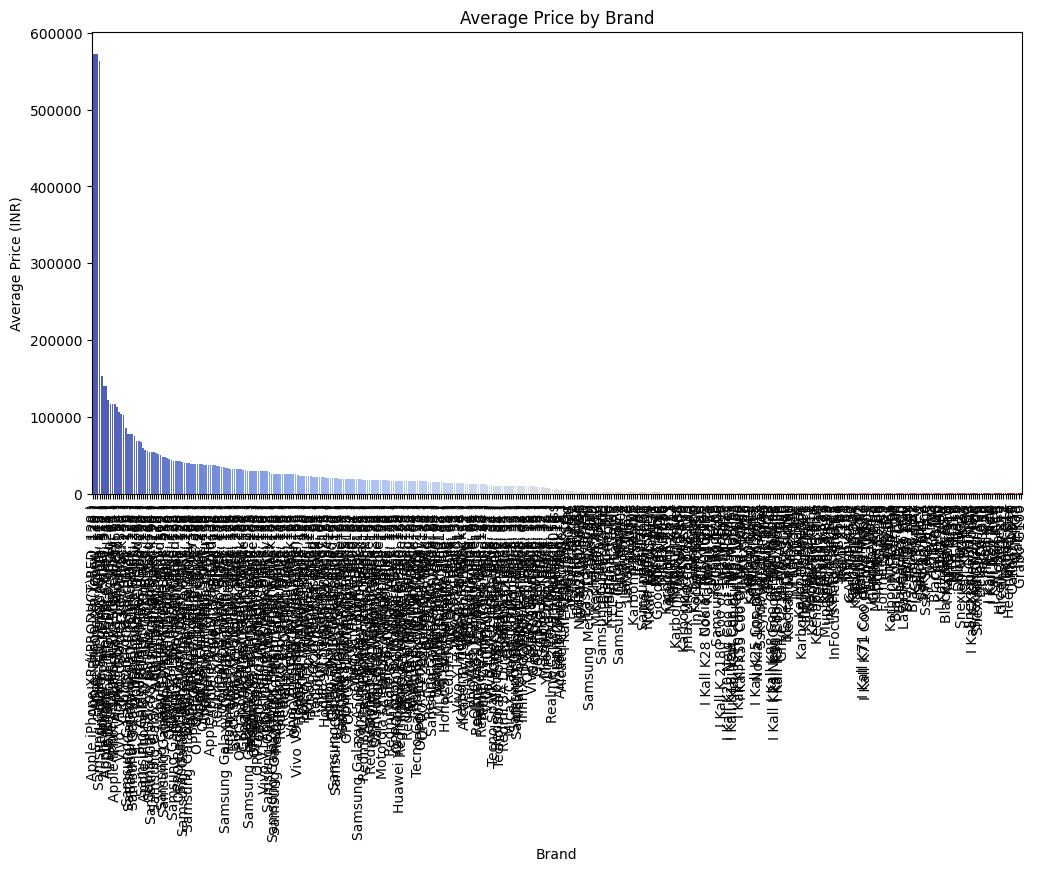

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate data to find the average price per brand
brand_prices = data.groupby("Brand_Name")["Price"].mean().reset_index()

# Sort values for better visualization
brand_prices = brand_prices.sort_values(by="Price", ascending=False)

# Create bar plot
plt.figure(figsize=(12,6))
sns.barplot(x="Brand_Name", y="Price", data=brand_prices, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Average Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (INR)")
plt.show()


Scatter Plot - Price vs. RAM

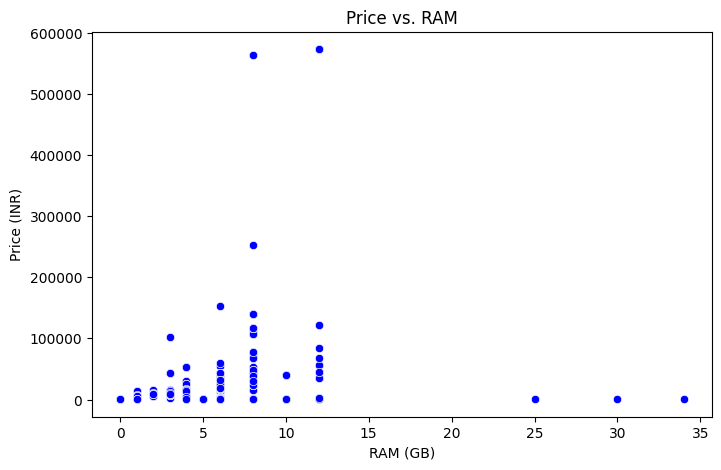

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="RAM", y="Price", data=data, color="blue")
plt.title("Price vs. RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.show()


Histogram - Price Distribution

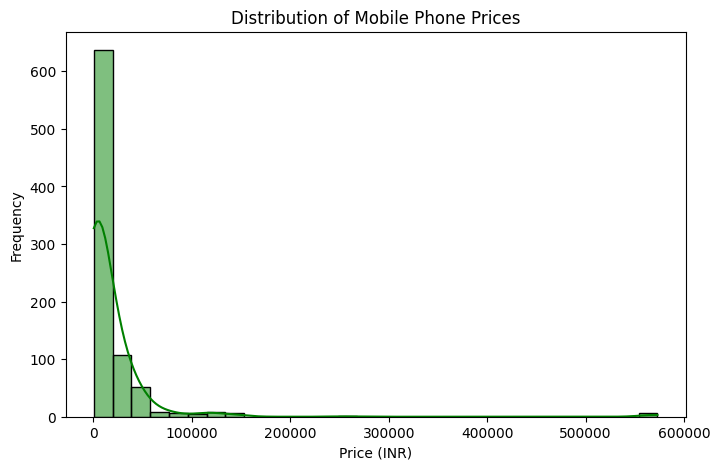

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data["Price"], bins=30, kde=True, color="green")
plt.title("Distribution of Mobile Phone Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.show()


Boxplot - Price Based on Battery Power






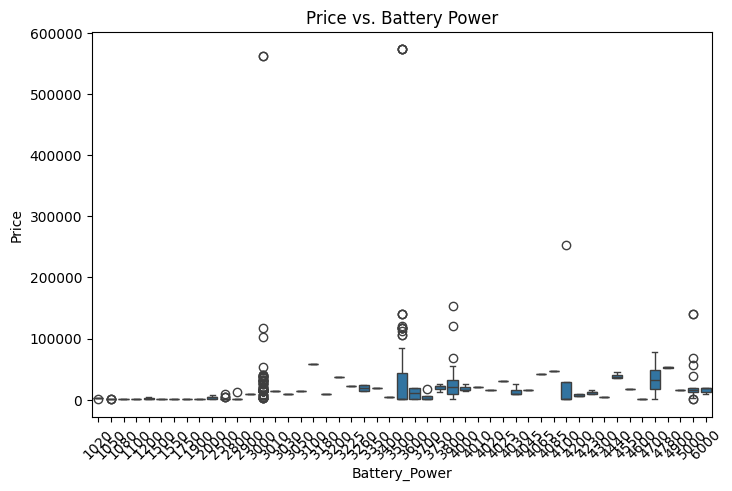

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Battery_Power", y="Price", data=data)
plt.xticks(rotation=45)
plt.title("Price vs. Battery Power")
plt.show()


 Correlation Heatmap

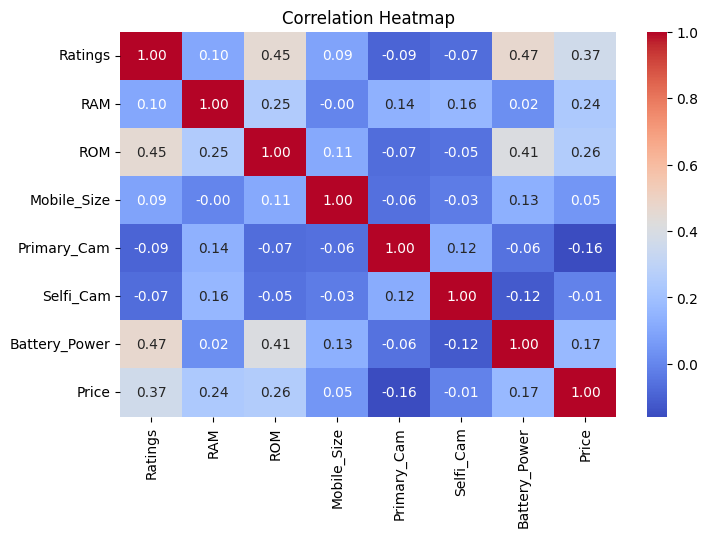

In [ ]:
import numpy as np
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()


# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


Feature Engineering
1.Convert categorical data (Brand_Name
to numerical.
2.Select important features for prediction.



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert Brand_Name to numerical values
encoder = LabelEncoder()
data["Brand_Name"] = encoder.fit_transform(data["Brand_Name"])

# Select features for prediction
X = data.drop(columns=["Price"])  # Features
y = data["Price"]  # Target Variable


Model Training;
We'll split data into training and testing sets and try Linear Regression as a simple statistical model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluate Model Performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")


Model Evaluation Metrics:
Mean Absolute Error (MAE): 15528.684284750234
Mean Squared Error (MSE): 1929063353.6136065
R-squared (R²): 0.17028566232602382


Install Required Libraries:



In [ ]:
pip install xgboost


Train Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
rf_pred = rf_model.predict(X_test)

# Evaluate Random Forest Model
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Model Performance:")
print(f"Mean Absolute Error (MAE): {rf_mae}")
print(f"Mean Squared Error (MSE): {rf_mse}")
print(f"R-squared (R²): {rf_r2}")


Random Forest Model Performance:
Mean Absolute Error (MAE): 3312.2737823258094
Mean Squared Error (MSE): 308351978.6658521
R-squared (R²): 0.8673739474289741


Train XGBoost Model

In [ ]:
from xgboost import XGBRegressor

# Train XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make Predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate XGBoost Model
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Model Performance:")
print(f"Mean Absolute Error (MAE): {xgb_mae}")
print(f"Mean Squared Error (MSE): {xgb_mse}")
print(f"R-squared (R²): {xgb_r2}")


XGBoost Model Performance:
Mean Absolute Error (MAE): 1806.1513671875
Mean Squared Error (MSE): 68486792.0
R-squared (R²): 0.9705429673194885


Compare Models

In [ ]:
# Compare Model Performance
models = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "MSE": [rf_mse, xgb_mse],
    "R² Score": [rf_r2, xgb_r2]
})

print(models)


           Model          MAE           MSE  R² Score
0  Random Forest  3312.273782  3.083520e+08  0.867374
1        XGBoost  1806.151367  6.848679e+07  0.970543


 Predict New Mobile Phone Prices:


In [ ]:
# Example new phone data
new_phones = pd.DataFrame({
    "Brand_Name": [2],  # Assuming you want to predict for the first brand (index 0)
    "Ratings": [4.5],
    "RAM": [8],
    "ROM": [128],
    "Mobile_Size": [6.5],
    "Primary_Cam": [64],
    "Selfi_Cam": [32],
    "Battery_Power": [5000]
})

# Predict with the best model
best_model = xgb_model if xgb_r2 > rf_r2 else rf_model
predicted_price = best_model.predict(new_phones)

print("Predicted Price:", predicted_price[0])

Predicted Price: 27741.672


Hyperparameter Tuning for Random Forest:
We'll tune n_estimators, max_depth, and min_samples_split for better performance

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
rf_params = {
    "n_estimators": [50, 100, 200],  # Number of trees
    "max_depth": [10, 20, None],  # Maximum depth of trees
    "min_samples_split": [2, 5, 10]  # Minimum samples to split a node
}

# Initialize Random Forest Model
rf_model = RandomForestRegressor(random_state=42)

# Perform Grid Search
rf_grid = GridSearchCV(rf_model, rf_params, cv=3, scoring="r2", n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Best Parameters & Model Performance
print("Best Parameters for Random Forest:", rf_grid.best_params_)

# Best Model
rf_best_model = rf_grid.best_estimator_

# Evaluate Best Random Forest Model
rf_best_pred = rf_best_model.predict(X_test)
rf_best_r2 = r2_score(y_test, rf_best_pred)

print("Tuned Random Forest R² Score:", rf_best_r2)


Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest R² Score: 0.8552471295969437


Hyperparameter Tuning for XGBoost
We will tune n_estimators, max_depth, and learning_rate.

In [ ]:
from xgboost import XGBRegressor

# Define the parameter grid
xgb_params = {
    "n_estimators": [50, 100, 200],  # Number of boosting rounds
    "max_depth": [3, 6, 10],  # Maximum tree depth
    "learning_rate": [0.01, 0.1, 0.3]  # Step size shrinkage
}

# Initialize XGBoost Model
xgb_model = XGBRegressor(random_state=42)

# Perform Grid Search
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=3, scoring="r2", n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Best Parameters & Model Performance
print("Best Parameters for XGBoost:", xgb_grid.best_params_)

# Best Model
xgb_best_model = xgb_grid.best_estimator_

# Evaluate Best XGBoost Model
xgb_best_pred = xgb_best_model.predict(X_test)
xgb_best_r2 = r2_score(y_test, xgb_best_pred)

print("Tuned XGBoost R² Score:", xgb_best_r2)


Best Parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Tuned XGBoost R² Score: 0.4574834704399109


Compare Tuned Models

In [ ]:
# Compare Model Performance
models = pd.DataFrame({
    "Model": ["Random Forest (Tuned)", "XGBoost (Tuned)"],
    "R² Score": [rf_best_r2, xgb_best_r2]
})

print(models)


                   Model  R² Score
0  Random Forest (Tuned)  0.855247
1        XGBoost (Tuned)  0.457483


Predict New Mobile Phone Price with Best Model


In [ ]:
# Select the best model
best_model = xgb_best_model if xgb_best_r2 > rf_best_r2 else rf_best_model

# Example new phone data
new_phones = pd.DataFrame({
    "Brand_Name": [0],
    "Ratings": [4.5],
    "RAM": [8],
    "ROM": [128],
    "Mobile_Size": [6.5],
    "Primary_Cam": [64],
    "Selfi_Cam": [32],
    "Battery_Power": [5000]
})

# Predict Price
predicted_price = best_model.predict(new_phones)
print("Predicted Price:", predicted_price[0])


Predicted Price: 31016.465
